1. Library


In [48]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder, MinMaxScaler
import joblib
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping

print("All libraries loaded successfully!")

All libraries loaded successfully!


2. Load data

In [49]:
# Load original data
df = pd.read_csv(r'C:\Users\Pongo\Desktop\DBS project\LowCortisol\DataScientist\dataKaggle_clean.csv')

print(f"Dataset shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")

print("\n=== Target yang tersedia ===")
print("Stress_Level:", df['Stress_Level'].unique())
print("Mental_Health_Condition:", df['Mental_Health_Condition'].unique())

print("\nDistribusi Stress_Level:")
print(df['Stress_Level'].value_counts())

Dataset shape: (5000, 19)
Columns: ['Age', 'Gender', 'Job_Role', 'Industry', 'Years_of_Experience', 'Work_Location', 'Hours_Worked_Per_Week', 'Number_of_Virtual_Meetings', 'Work_Life_Balance_Rating', 'Stress_Level', 'Mental_Health_Condition', 'Access_to_Mental_Health_Resources', 'Productivity_Change', 'Social_Isolation_Rating', 'Satisfaction_with_Remote_Work', 'Company_Support_for_Remote_Work', 'Physical_Activity', 'Sleep_Quality', 'Region']

=== Target yang tersedia ===
Stress_Level: <StringArray>
['Medium', 'High', 'Low']
Length: 3, dtype: str
Mental_Health_Condition: <StringArray>
['Depression', 'Anxiety', nan, 'Burnout']
Length: 4, dtype: str

Distribusi Stress_Level:
Stress_Level
High      1686
Medium    1669
Low       1645
Name: count, dtype: int64


3. Preprocessing

In [50]:
# ================== PILIH TARGET ==================
target = 'Stress_Level'   # ← Ganti ke 'Mental_Health_Condition' jika mau

X = df.drop(columns=[target])
y = df[target]

print(f"Target: {target}")
print(y.value_counts())

Target: Stress_Level
Stress_Level
High      1686
Medium    1669
Low       1645
Name: count, dtype: int64


4. ENCODING

In [51]:
# Encoding categorical
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    encoders[col] = le

# Label encode target
le_target = LabelEncoder()
y_encoded = le_target.fit_transform(y)

C:\Users\Pongo\AppData\Local\Temp\ipykernel_11588\2830943635.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include=['object']).columns.tolist()


INDEPENDENT TEST

In [52]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

5. Save preprocessing and scaling

In [53]:
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training shape: {X_train_scaled.shape}")
print(f"Test shape: {X_test_scaled.shape}")

# Save preprocessors
joblib.dump(encoders, 'encoders.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(le_target, 'le_target.pkl')

Training shape: (4000, 18)
Test shape: (1000, 18)


['le_target.pkl']

Custom layer 

In [54]:
# class FeatureAttentionLayer(layers.Layer):
#     def __init__(self, **kwargs):
#         super().__init__(**kwargs)
        
#     def build(self, input_shape):
#         input_dim = int(input_shape[-1])
#         self.attention_weights = self.add_weight(
#             shape=(input_dim, 1),
#             initializer='glorot_uniform',
#             trainable=True,
#             name='attention_weights'
#         )
#         super().build(input_shape)
    
#     def call(self, inputs, training=None):
#         attention_scores = tf.matmul(inputs, self.attention_weights)
#         attention_scores = tf.squeeze(attention_scores, axis=-1)
#         attention_weights = tf.nn.softmax(attention_scores, axis=-1)
#         attention_weights = tf.expand_dims(attention_weights, axis=-1)
#         return tf.multiply(inputs, attention_weights)

In [55]:
from imblearn.over_sampling import SMOTE
from sklearn.utils.class_weight import compute_class_weight

# SMOTE untuk balancing training data
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

print("After SMOTE:", pd.Series(y_train_resampled).value_counts())
# Hitung class weights
class_weights = compute_class_weight('balanced', classes=np.unique(y_train_resampled), y=y_train_resampled)
class_weight_dict = dict(enumerate(class_weights))

print("Class Weights:", class_weight_dict)

# ====================== BUILD MODEL ======================
def build_improved_model(input_dim):
    inputs = layers.Input(shape=(X_train_resampled.shape[1],))
    
    x = layers.Dense(128, activation='relu')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.1)(x)

    x = layers.Dense(64, activation='relu')(x)
    x = layers.BatchNormalization()(x)

    outputs = layers.Dense(3, activation='softmax')(x)
    return models.Model(inputs, outputs)


model = build_improved_model(X_train_scaled.shape[1])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.005),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

After SMOTE: 1    1349
0    1349
2    1349
Name: count, dtype: int64
Class Weights: {0: np.float64(1.0), 1: np.float64(1.0), 2: np.float64(1.0)}


Custom Callback

In [56]:
from tensorflow.keras import callbacks
import numpy as np

class PerformanceThresholdCallback(callbacks.Callback):
    """
    Custom Callback:
    - Stop training jika validation accuracy mencapai threshold tertentu
    - Simpan model terbaik
    - Print progress yang informatif
    """
    def __init__(self, accuracy_threshold=0.85, monitor='val_accuracy', patience=10):
        super().__init__()
        self.accuracy_threshold = accuracy_threshold
        self.monitor = monitor
        self.patience = patience
        self.best_val_acc = 0.0
        self.wait = 0
        self.stopped_epoch = 0
        
    def on_epoch_end(self, epoch, logs=None):
        if logs is None:
            logs = {}
            
        current_val_acc = logs.get(self.monitor)
        current_train_acc = logs.get('accuracy')
        
        if current_val_acc is None:
            return
        
        # Update best accuracy
        if current_val_acc > self.best_val_acc:
            self.best_val_acc = current_val_acc
            self.wait = 0
            print(f"✅ Epoch {epoch+1:3d}: Val Accuracy improved to {current_val_acc:.4f} (Best)")
        else:
            self.wait += 1
        
        # Print progress setiap epoch
        print(f"Epoch {epoch+1:3d} - "
              f"Train Acc: {current_train_acc:.4f} - "
              f"Val Acc: {current_val_acc:.4f} - "
              f"Best Val: {self.best_val_acc:.4f}")
        
        # Cek apakah sudah mencapai target
        if current_val_acc >= self.accuracy_threshold:
            print(f"\n🎉🎉 TARGET ACCURACY TERCAI ({current_val_acc:.4f}) pada epoch {epoch+1}!")
            print(f"Training dihentikan lebih awal.")
            self.model.stop_training = True
            self.stopped_epoch = epoch + 1

TRAINING

classweight

In [57]:
# ====================== TRAINING ======================
from datetime import datetime
%pip install -q tensorboard
# Callbacks
custom_callback = PerformanceThresholdCallback(accuracy_threshold=0.85)

early_stopping = callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=15,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_accuracy',
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

tensorboard_callback = callbacks.TensorBoard(
    log_dir=f"logs/fit_{datetime.now().strftime('%Y%m%d-%H%M%S')}",
    histogram_freq=1
)

print("🚀 Training dimulai...\n")

history = model.fit(
    X_train_resampled, y_train_resampled,
    validation_split=0.2,
    class_weight=class_weight_dict,
    epochs=300,
    batch_size=64,
    # callbacks=[
    #     PerformanceThresholdCallback(accuracy_threshold=0.70),  # turunkan target dulu
    #     callbacks.EarlyStopping(monitor='val_accuracy', patience=12, restore_best_weights=True),
    #     callbacks.ReduceLROnPlateau(monitor='val_accuracy', factor=0.5, patience=4, min_lr=1e-6)
    # ],
    verbose=1
)

Note: you may need to restart the kernel to use updated packages.
🚀 Training dimulai...

Epoch 1/300



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


51/51 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.3309 - loss: 1.2664 - val_accuracy: 0.3173 - val_loss: 1.1055
Epoch 2/300
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3859 - loss: 1.1013 - val_accuracy: 0.3173 - val_loss: 1.1045
Epoch 3/300
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4186 - loss: 1.0785 - val_accuracy: 0.3062 - val_loss: 1.1109
Epoch 4/300
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4306 - loss: 1.0681 - val_accuracy: 0.3210 - val_loss: 1.1168
Epoch 5/300
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4356 - loss: 1.0600 - val_accuracy: 0.3173 - val_loss: 1.1262
Epoch 6/300
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4526 - loss: 1.0409 - val_accuracy: 0.3420 - val_loss: 1.1382
Epoch 7/300
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4486 - loss: 1.0476 - val_accuracy: 0.3346 - val_loss: 1.1363
Epoch 8/300
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4690 - loss: 1.0299 - val_accuracy: 0.3259 - val_loss: 1.1

EVALUASI


FINAL TEST RESULTS
Test Accuracy : 0.3160 (31.60%)
Test Loss     : 2.9575

Classification Report:
              precision    recall  f1-score   support

        High       0.32      0.27      0.29       337
         Low       0.31      0.36      0.33       329
      Medium       0.32      0.32      0.32       334

    accuracy                           0.32      1000
   macro avg       0.32      0.32      0.32      1000
weighted avg       0.32      0.32      0.31      1000



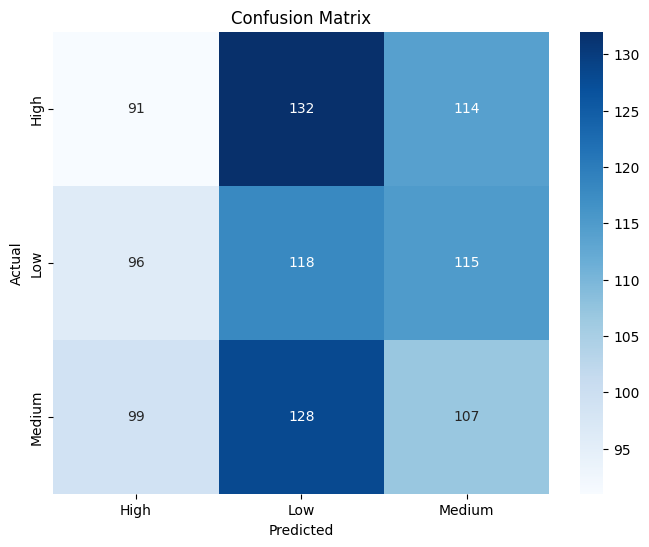

In [58]:
# ====================== EVALUATION ======================
test_loss, test_acc = model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"\n{'='*60}")
print(f"FINAL TEST RESULTS")
print(f"{'='*60}")
print(f"Test Accuracy : {test_acc:.4f} ({test_acc*100:.2f}%)")
print(f"Test Loss     : {test_loss:.4f}")

y_pred = np.argmax(model.predict(X_test_scaled, verbose=0), axis=1)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, 
                          target_names=le_target.classes_))

# Confusion Matrix
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test, y_pred), 
            annot=True, fmt='d', cmap='Blues',
            xticklabels=le_target.classes_,
            yticklabels=le_target.classes_)
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()